# Домашнее задание. Свёрточные сети

Здесь вам предстоит построить и обучить свою первую свёрточную сеть для классификации изображений на данных CIFAR10.

In [2]:
import tensorflow as tf

from tqdm import tqdm_notebook

## Данные

CIFAR10
* 60000 RGB изображений размером 32x32x3
* 10 классов: самолёты, собаки, рыбы и т.п.

<img src="https://www.samyzaf.com/ML/cifar10/cifar1.jpg" style="width:60%">

Загрузите данные, разделите их на обучающую и тестовую выборки. Размер тестовой выборки должен быть $10^4$.

In [3]:
import numpy as np
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10**4, random_state=42)

class_names = np.array(['airplane','automobile ','bird ','cat ','deer ','dog ','frog ','horse ','ship ','truck'])

print (X_train.shape,y_train.shape)

(40000, 32, 32, 3) (40000, 1)


Прежде чем приступать к основной работе, стоит убедиться что загруженно именно то, что требовалось:

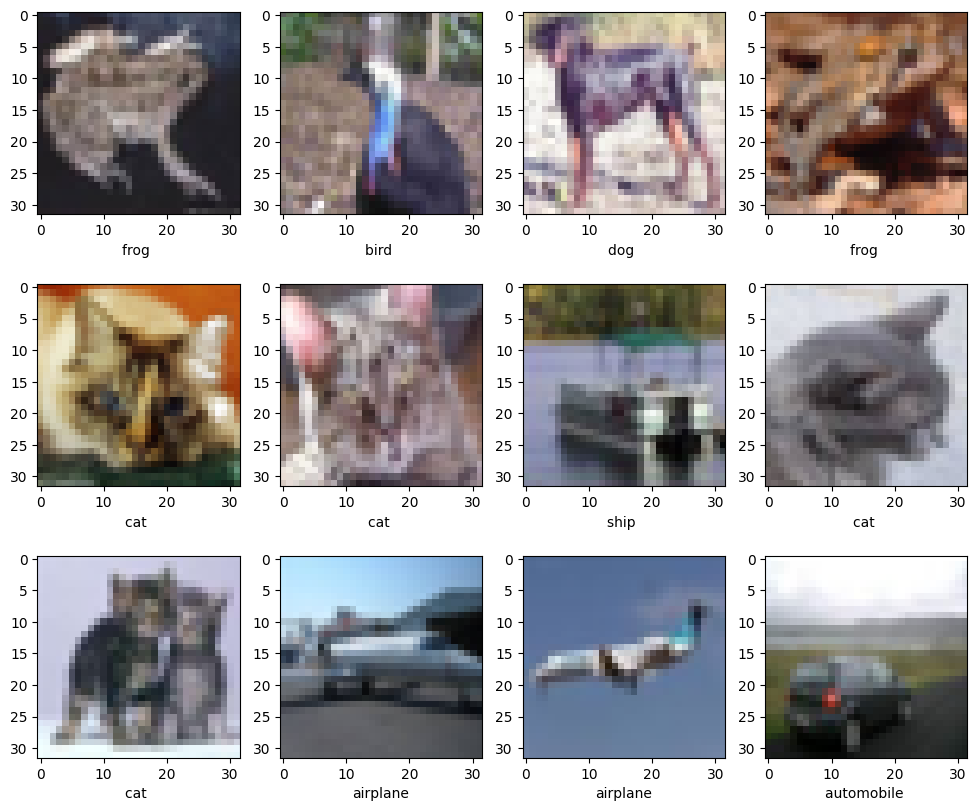

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xlabel(class_names[y_train[i, 0]])
    plt.imshow(X_train[i])

## Подготовка данных

Сейчас каждый пиксель изображения закодирован тройкой чисел (RGB) __от 0 до 255__. Однако лучше себя показывает подход, где значения входов нейросети распределены недалеко от 0.

Давайте приведём все данные в диапазон __`[0, 1]`__ — просто разделим на соответствующий коэффициент:

In [5]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

Исполните код ниже для проверки, что все выполнено корректно.

In [6]:
assert np.shape(X_train) == (40000, 32, 32, 3), "data shape should not change"
assert 0.9 <= max(map(np.max, (X_train, X_val, X_test))) <= 1.05
assert 0.0 <= min(map(np.min, (X_train, X_val, X_test))) <= 0.1
assert len(np.unique(X_test / 255.)) > 10, "make sure you casted data to float type"

## Архитектура сети

Для начала реализуйте простую нейросеть:
1. принимает на вход картинки размера 32 x 32 x 3;
2. вытягивает их в вектор (`keras.layers.Flatten`);
3. пропускает через 1 или 2 полносвязных слоя;
4. выходной слой отдает вероятности принадлежности к каждому из 10 классов.

Создайте полносвязную сеть:

In [7]:
import keras
from keras import layers as L
from keras import backend as K

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [9]:
dummy_pred = model.predict(X_train[:20])
assert dummy_pred.shape == (20, 10)
assert np.allclose(dummy_pred.sum(-1), 1)
print("Успех!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Успех!


## Обучение сети

**Задание 1.1 (обязательно)** Будем минимизировать многоклассовую кроссэкнропию с помощью __sgd__. Вам нужно получить сеть, которая достигнет __не менее 45%__ __accuracy__ на тестовых данных.

__Важно:__ поскольку в y_train лежат номера классов, Керасу нужно либо указать sparse функции потерь и метрики оценки качества классификации (`sparse_categorical_crossentropy` и `sparse_categorical_accuracy`), либо конвертировать метки в one-hot формат.

### Полезные советы
* `model.compile` позволяет указать, какие метрики вы хотите вычислять.
* В `model.fit` можно передать валидационную выборку (`validation_data=[X_val, y_val]`), для отслеживания прогресса на ней. Также рекомендуем сохранять результаты в [tensorboard](https://keras.io/callbacks/#tensorboard) или [wandb](https://docs.wandb.ai/integrations/jupyter). **Важно: логи tensorboard не получится без боли посмотреть через colab.** Workaround: скачать логи и запустить tensorboard локально или помучаться [с этим](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).
* По умолчанию сеть учится 1 эпоху. Совсем не факт, что вам этого хватит. Число эпох можно настроить в методе `fit` (`epochs`).
* Ещё у Кераса есть много [полезных callback-ов](https://keras.io/callbacks/), которые можно попробовать. Например, автоматическая остановка или подбор скорости обучения.

In [10]:
y_train, y_val = (keras.utils.to_categorical(y) for y in (y_train, y_val))

In [11]:
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),
             tf.keras.callbacks.EarlyStopping(monitor="val_categorical_accuracy", mode="max", patience=7, restore_best_weights=True)]

In [12]:
model.compile(optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"])
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=16, epochs=32, callbacks=callbacks)

Epoch 1/32
2496/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.2744 - loss: 2.0268

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.2745 - loss: 2.0265 - val_categorical_accuracy: 0.3601 - val_loss: 1.7541
Epoch 2/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.3813 - loss: 1.7146

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - categorical_accuracy: 0.3813 - loss: 1.7146 - val_categorical_accuracy: 0.3920 - val_loss: 1.7143
Epoch 3/32
2490/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4129 - loss: 1.6387

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - categorical_accuracy: 0.4130 - loss: 1.6386 - val_categorical_accuracy: 0.4214 - val_loss: 1.6147
Epoch 4/32
2485/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4287 - loss: 1.5911

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - categorical_accuracy: 0.4287 - loss: 1.5911 - val_categorical_accuracy: 0.4255 - val_loss: 1.6066
Epoch 5/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4360 - loss: 1.5658

...

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - categorical_accuracy: 0.4946 - loss: 1.4127 - val_categorical_accuracy: 0.4541 - val_loss: 1.5419
Epoch 16/32
2495/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4969 - loss: 1.4100

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.4969 - loss: 1.4100 - val_categorical_accuracy: 0.4520 - val_loss: 1.5442
Epoch 17/32
2491/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.5005 - loss: 1.3968

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.5005 - loss: 1.3969 - val_categorical_accuracy: 0.4461 - val_loss: 1.5725
Epoch 18/32
2487/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5067 - loss: 1.3780

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.5066 - loss: 1.3781 - val_categorical_accuracy: 0.4499 - val_loss: 1.5649
Epoch 19/32
2486/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5004 - loss: 1.3946

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.5004 - loss: 1.3946 - val_categorical_accuracy: 0.4612 - val_loss: 1.5146


А теперь можно проверить качество вашей сети, выполнив код ниже:

In [13]:
from sklearn.metrics import accuracy_score

predict_x=model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.45, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step

 Test_acc = 0.4625
 Not bad!


## Карманная сверточная сеть

**Задание 1.2 (обязательно)** Реализуйте небольшую свёрточную сеть. Совсем небольшую:
1. Входной слой
2. Свёртка 3x3 с 10 фильтрами
3. Нелинейность на ваш вкус
4. Max-pooling 2x2
5. Вытягиваем оставшееся в вектор (Flatten)
6. Полносвязный слой на 100 нейронов
7. Нелинейность на ваш вкус
8. Выходной полносвязный слой с softmax

Обучите её так же, как и предыдущую сеть. Если всё хорошо, у вас получится accuracy не меньше __50%__.

In [14]:
new_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=(3, 3),
                           padding='same',
                           activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])

In [15]:
new_callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='new_model.{epoch:02d}-{val_loss:.2f}.h5'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),
             tf.keras.callbacks.EarlyStopping(patience=3)]

In [16]:
new_model.compile(optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"])
new_model.fit(X_train, y_train, batch_size=16, epochs=32, callbacks=new_callbacks, validation_split=0.2)

Epoch 1/32
1990/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.3619 - loss: 1.7741

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.3623 - loss: 1.7729 - val_categorical_accuracy: 0.4781 - val_loss: 1.4299
Epoch 2/32
1988/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.5383 - loss: 1.3085

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.5384 - loss: 1.3084 - val_categorical_accuracy: 0.5435 - val_loss: 1.2737
Epoch 3/32
1976/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.5866 - loss: 1.1701

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.5866 - loss: 1.1702 - val_categorical_accuracy: 0.5642 - val_loss: 1.2342
Epoch 4/32
1983/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.6168 - loss: 1.0936

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.6168 - loss: 1.0937 - val_categorical_accuracy: 0.5830 - val_loss: 1.1827
Epoch 5/32
1989/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.6438 - loss: 1.0149

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.6438 - loss: 1.0150 - val_categorical_accuracy: 0.5876 - val_loss: 1.1765
Epoch 6/32
1993/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.6616 - loss: 0.9661

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.6616 - loss: 0.9661 - val_categorical_accuracy: 0.5796 - val_loss: 1.2010
Epoch 7/32
1995/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.6786 - loss: 0.9218

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.6786 - loss: 0.9218 - val_categorical_accuracy: 0.5899 - val_loss: 1.1964
Epoch 8/32
1999/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.6978 - loss: 0.8584

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.6978 - loss: 0.8585 - val_categorical_accuracy: 0.5909 - val_loss: 1.1954


Давайте посмотрим, смогла ли карманная сверточная сеть побить заданный порог по качеству:

In [17]:
from sklearn.metrics import accuracy_score

predict_x = new_model.predict(X_test)
classes_x = np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.50, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step

 Test_acc = 0.6033
 Not bad!


## Учимся учить

А теперь научимся сравнивать кривые обучения моделей — зависимости значения accuracy от количества итераций.

Вам потребуется реализовать _экспериментальный стенд_ — вспомогательный код, в который вы сможете подать несколько архитектур и методов обучения, чтобы он их обучил и вывел графики кривых обучения. Это можно сделать с помощью `keras.callbacks` — `TensorBoard` или `History`.

Будьте морально готовы, что на обучение уйдёт _много времени_. Даже если вы ограничитесь 10 эпохами. Пока идёт обучение, вы можете переключиться на другие задания или заняться чем-нибудь приятным: поспать, например.

**Задание 1.3 (опционально)** Попробуйте использовать различные методы оптимизации (sgd, momentum, adam) с параметрами по умолчанию. Какой из методов работает лучше?

Для удобства напишем класс Evaluator, который принимает в себя дикты виды {имя_оптимайзера: инстанс}, {имя модели: инстанс} и обучает всевозможные комбинации моделей с оптимайзерами при помощи метода fit (попутно записывая логи отдельно для каждой модели). Также пригодится метод evaluate для отображения итоговых скоров.

Пользоваться классом не обязательно. По умолчанию класс использует tensorboard. Если вы выше использовали wandb -- советуем дописать callback.

In [18]:
class Evaluator(list):
    def __init__(self, models, optimizers='adam', loss=keras.losses.categorical_crossentropy,
                 metrics=[keras.metrics.categorical_accuracy]):
        '''
            models: dict {name: model}
            optimizers: list of optimizers or just one optimizer
        '''
        if not isinstance(models, dict):
            models = {'single_model': models}
        if not isinstance(optimizers, dict):
            optimizers = {str(optimizers.__class__): optimizers}
        super().__init__([(model_name, keras.models.clone_model(model), optimizer_name, optimizer)
                          for model_name, model in models.items()
                          for optimizer_name, optimizer in optimizers.items()])
        for _, model, _, optimizer in self:
            model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def fit(self, X, y, validation_data=(), max_epochs=100, verbose=0, callbacks=[], batch_size=32):
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):
            model.fit(X, y, validation_data=validation_data or None, epochs=max_epochs, verbose=verbose,
                      batch_size=batch_size, callbacks=callbacks + [keras.callbacks.TensorBoard(
                          log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def fit_generator(self, X, y, validation_data=(), max_epochs=100, verbose=1, callbacks=[], batch_size=32):
        datagen = keras.preprocessing.image.ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True
        )
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):
            model.fit_generator(datagen.flow(X, y, batch_size=batch_size), epochs=max_epochs,
                validation_data=validation_data or None, verbose=verbose,
                callbacks=callbacks + [keras.callbacks.TensorBoard(
                    log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def evaluate(self, X, y, metric):
        for model_name, model, optimizer_name, _ in self:
            print('Final score of {}_{} is {}'.format(model_name, optimizer_name,
                  metric(y_test, model.predict(X_test).argmax(axis=1))))

In [19]:
!rm -rf ./logs

In [20]:
from tensorflow.keras import optimizers

optimizers = {
    'sgd': keras.optimizers.SGD(
        learning_rate=0.01
    ),

    'sgd_momentum': keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    'adam': keras.optimizers.Adam(
        learning_rate=0.001
    )
}

In [21]:
evaluator = Evaluator(model, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val))
evaluator.evaluate(X_test, y_test, accuracy_score)

/var/folders/6w/fwb_07rx7c3_dpz1j_x3zv880000gn/T/ipykernel_1216/2505868840.py:21: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/3 [00:00<?, ?it/s]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
Final score of single_model_sgd is 0.5308
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step
Final score of single_model_sgd_momentum is 0.4818
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step
Final score of single_model_adam is 0.4623


In [22]:
!pwd

/Users/acer/Downloads


Для этой архитектуры и выбранных параметров наиболее эффективным оказался SGD с learning_rate=0.01. Однако нельзя утверждать, что SGD всегда лучше: проведён только один запуск, использовались разные начальные веса и не выполнялся подбор скорости обучения. Для более надёжного сравнения необходимо провести несколько запусков и сравнивать среднюю точность на валидационной, а не тестовой выборке.

**Задание 1.4 (опционально)** Добавьте нормализацию по батчу (`BatchNormalization`) между свёрткой и активацией. Попробуйте использовать несколько нормализаций — в свёрточных и полносвязных слоях.

Для удобства реализуем класс Models, который по сути будет являться списком моделей с двумя методами: add (добавить слой ко всем моделям) и add_create (создать новую модель на основе базовой с дополнительным слоем). Пользоваться им необязательно, но вдруг :)

In [23]:
from collections import OrderedDict

class Models(OrderedDict):
    def __init__(self, models):
        if not isinstance(models, dict):
            models = OrderedDict({'base_model': models})
        super().__init__(models)

    def add(self, layer):
        for name, model in self.items():
            model.add(layer)

    def add_create(self, name, layer):
        base_model = next(iter(self.items()))[1]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

    def add_update(self, name, layer):
        base_model = self[next(reversed(self))]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

# Example of usage
# models = Models(keras.Sequential())
# models.add(L.InputLayer(input_shape=(32, 32, 3)))
# models.add(L.Convolution2D(filters=10, kernel_size=(3, 3)))
# models.add(L.MaxPooling2D())
# models.add_create('conv_batchnorm', L.BatchNormalization())
# models.add(L.Activation('relu'))
# ...

Прокомментируйте полученные результаты.

**Задание 1.5 (опционально)** Посмотрите на batch_size (параметр model.fit) - при большем батче модель будет быстрее проходить эпохи, но с совсем огромным батчом вам потребуется больше эпох для сходимости (т.к. сеть делает меньше шагов за одну эпоху).
Найдите такое значение, при котором модель быстрее достигает точности 55%. **Hint**: используйте early stopping callback.

**Задание 1.6 (опционально)** Попробуйте найти такую комбинацию метода обучения и нормализации, при которой сеть имеет наилучшую кривую обучения. Поясните, что вы понимаете под "наилучшей" кривой обучения.

## Свёрточная нейросеть здорового человека

**Задание 1.7 (обязательно попытаться)** Наигравшись выше, обучим большую свёрточную сеть, которая даст на тестовой выборке __accuracy больше 80%__. В этом задании вам потребуется провести эксперименты, сравнив их между собой в конце. Возможно, может быть несколько проще, если писать выводы во время или сразу после каждого эксперимента, после чего сделать общие выводы.

Рекомендуем начать с лучшей модели предыдущего задания и постепенно её улучшать. Вы можете использовать всё, что угодно: любые активации, сколь угодно большие свёрточные слои и глубокие сети. Единственное ограничение: __нельзя использовать предобученные сети и дополнительные данные__.

### Полезные советы
* Для начала, неплохо бы научить что-нибудь побольше, чем 10 фильтров 3x3.
* __Главное правило: одно изменение на эксперимент__. Если у вас есть 2 идеи по улучшению сети, сначала попробуйте их независимо. Может оказаться, что одно из них дало __+10%__ точности а другое __-7%__. А вы так и будете думать, что сделали 2 полезных изменения которые в сумме дают __+3%__. Если какая-то идея не работает — даже если она вам нравится - опишите ее и выкидывайте из дальнейших экспериментов.
* __Be careful or you will dropout__. Дропаут (`L.Dropout`) может позволить вам обучить в несколько раз бОльшую сеть без переобучения, выжав несколько процентов качества. Это круто, но не стоит сразу ставить dropout 50%. Во-первых, слишком сильный дропаут только ухудшит сеть (underfitting). Во-вторых, даже если дропаут улучшает качество, он замедляет обучение. Рекомендуем начинать с небольшого дропаута, быстро провести основные эксперименты, а потом жахнуть в 2 раза больше нейронов и дропаута ~~на ночь~~.
* __Аугментация данных__. Если котика слегка повернуть и подрезать (простите), он всё равно останется котиком. А в керасе есть [удобный класс](https://keras.io/preprocessing/image/), который поставит подрезание котиков на поток. Ещё можно сделать этот трюк в тесте: вертим картинку 10 раз, предсказываем вероятности и усредняем. Только один совет: прежде, чем учить, посмотрите глазами на аугментированные картинки. Если вы сами не можете их различить, то и сеть не сможет.
* __Don't just stack more layers__. Есть более эффективные способы организовать слои, чем простой Sequential. Вот пара идей: [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions](https://arxiv.org/abs/1608.06993). Только не копируйте архитектуру подчистую — вам скорее всего хватит меньшего размера.
* __Долго != плохо__. Более глубокие архитектуры обычно требуют бОльше эпох до сходимости. Это значит, что в первые несколько эпох они могут быть хуже менее глубоких аналогов. Дайте им время, запаситесь чаем и обмажьтесь batch-norm-ом.

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [32]:
val_datagen = ImageDataGenerator()

dg_x_train, dg_x_val = X_train, X_val
dg_y_train, dg_y_val = y_train, y_val

In [42]:
final_model = keras.Sequential([
    L.Input(shape=(32, 32, 3)),

    L.Conv2D(32, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.Conv2D(32, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.MaxPooling2D(),
    L.Dropout(0.15),

    L.Conv2D(64, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.Conv2D(64, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.MaxPooling2D(),
    L.Dropout(0.20),

    L.Conv2D(128, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.Conv2D(128, 3, padding="same", use_bias=False),
    L.BatchNormalization(),
    L.Activation("relu"),
    L.MaxPooling2D(),
    L.Dropout(0.30),

    L.GlobalAveragePooling2D(),
    L.Dense(256, activation="relu"),
    L.Dropout(0.40),
    L.Dense(10, activation="softmax")
])

In [43]:
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

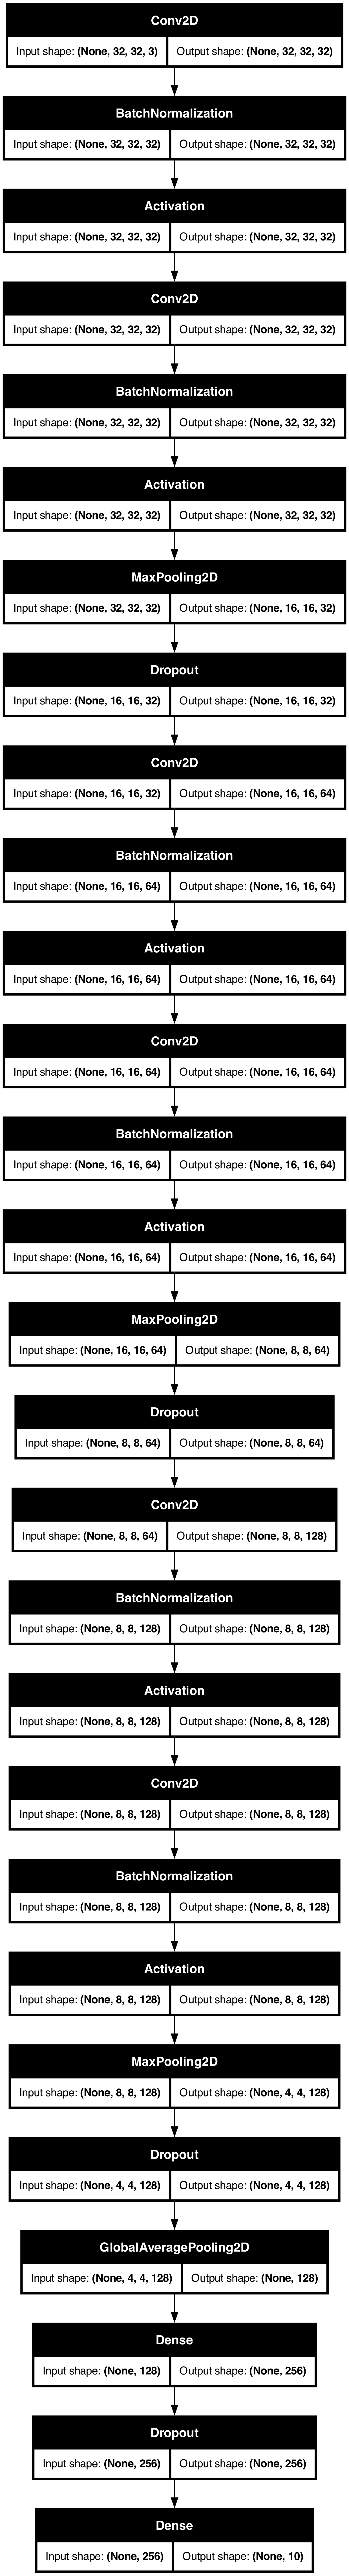

In [39]:
tf.keras.utils.plot_model(final_model, '123.png', show_shapes=True)

In [44]:
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)
final_model.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=32, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/32


/Users/acer/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 48s 19ms/step - categorical_accuracy: 0.3414 - loss: 1.7919 - val_categorical_accuracy: 0.4341 - val_loss: 1.6763
Epoch 2/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 49s 20ms/step - categorical_accuracy: 0.5414 - loss: 1.2882 - val_categorical_accuracy: 0.5263 - val_loss: 1.4322
Epoch 3/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 51s 20ms/step - categorical_accuracy: 0.5931 - loss: 1.1559 - val_categorical_accuracy: 0.6223 - val_loss: 1.1006
Epoch 4/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - categorical_accuracy: 0.6303 - loss: 1.0581 - val_categorical_accuracy: 0.6484 - val_loss: 0.9919
Epoch 5/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - categorical_accuracy: 0.6699 - loss: 0.9579 - val_categorical_accuracy: 0.6988 - val_loss: 0.8573
Epoch 6/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 53s 21ms/step - categorical_accuracy: 0.6922 - loss: 0.8959 - val_categorical_accuracy: 0.7328 - val_loss: 0.7609
Epoch 7/32
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 54s 22ms/step - categorical_accur

Момент истины: проверьте, какого качества достигла ваша сеть.

In [45]:
from sklearn.metrics import accuracy_score

predict_x=final_model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

 Test_acc = 0.8344
Это победа!


А теперь, опишите свои <s>ощущения</s> результаты от проведенных экспериментов.

Для финального эксперимента была создана глубокая свёрточная сеть из трёх блоков с 32, 64 и 128 фильтрами. В каждом блоке использовались две свёртки, Batch Normalization, ReLU, MaxPooling и Dropout. После свёрточных блоков применялись Global Average Pooling, полносвязный слой на 256 нейронов и выходной слой softmax.
Для обучения использовалась аугментация изображений: повороты, сдвиги и горизонтальные отражения. Оптимизатором был Adam. Наилучший результат на валидационной выборке был достигнут на 17-й эпохе: validation accuracy = 83.70%, validation loss = 0.4845. После этого validation loss начал увеличиваться, поэтому Early Stopping остановил обучение и восстановил веса лучшей эпохи.


На тестовой выборке модель достигла accuracy 83.44%, превысив требуемый порог 80%. По сравнению с полносвязной сетью (47.05%) качество выросло на 36.39 процентных пункта, а по сравнению с небольшой свёрточной сетью (58.99%) — на 24.45 процентных пункта.
Разрыв между training и validation accuracy в некоторых эпохах не является ошибкой: во время обучения применялись Dropout и аугментация, которые усложняют примеры, а при валидации они отключаются. Наиболее полезными улучшениями стали увеличение глубины и числа фильтров, нормализация по батчу, Dropout, аугментация и восстановление весов лучшей эпохи.